In [ ]:
import os
import librosa
import pandas as pd
import numpy as np

audio_folder = "C:\\Users\\Probook\\Downloads\\cv-valid-train"

def extract_features(audio_path):
    try:
        audio, sr = librosa.load(audio_path)
        
        # Pitch
        pitches, magnitudes = librosa.piptrack(y=audio, sr=sr)
        pitch = np.mean(pitches[magnitudes > np.median(magnitudes)])
        
        # Intensity (RMS energy)
        intensity = librosa.feature.rms(y=audio).mean()
        
        # Duration
        duration = librosa.get_duration(y=audio, sr=sr)
        
        # Spectral Centroid
        spectral_centroid = librosa.feature.spectral_centroid(y=audio, sr=sr).mean()
        
        return [pitch, intensity, duration, spectral_centroid]
    except Exception as e:
        print(f"Error processing {audio_path}: {str(e)}")
        return [None, None, None, None]

# List to hold all features
features_list = []

# Iterate through each file in the directory
for filename in os.listdir(audio_folder):
    if filename.endswith(".mp3"):
        # Full path of the audio file
        file_path = os.path.join(audio_folder, filename)
        
        # Extract features
        features = extract_features(file_path)
        
        # Append features along with the filename
        features_list.append([filename] + features)

df_features = pd.DataFrame(features_list, columns=['filename', 'pitch', 'intensity', 'duration', 'spectral_centroid'])

df_features.to_csv('extracted_audio_features.csv', index=False)

print("Features extraction complete and saved to 'extracted_audio_features.csv'.")

Features extraction complete and saved to 'extracted_audio_features.csv'.


In [ ]:
df=pd.read_csv("C:\\Users\\Probook\\Downloads\\extracted_audio_features.csv")
df

,filename,pitch,intensity,duration,spectral_centroid
0,sample-000000.mp3,1416.6956,0.065184,4.104036,2194.864245
1,sample-000001.mp3,1889.0800,0.001252,7.560000,3170.069503
2,sample-000002.mp3,1639.6227,0.041539,5.064036,2866.001347
3,sample-000003.mp3,1559.5930,0.007681,6.648027,2436.612042
4,sample-000004.mp3,1194.2878,0.386169,4.896009,2406.467947
...,...,...,...,...,...
14999,sample-014999.mp3,1120.4126,0.072214,8.304036,2159.182047
15000,sample-015000.mp3,1743.4628,0.076984,3.864036,2266.039206
15001,sample-015001.mp3,1771.9946,0.031853,3.528027,2591.373500
15002,sample-015002.mp3,1319.0045,0.013741,5.784036,2471.368183


In [ ]:
df_main = pd.read_csv("C:\\Users\Probook\\Downloads\\truncated_train.csv")  

In [ ]:
df_main = pd.read_csv("C:\\Users\Probook\\Downloads\\truncated_train.csv")  
df_features = pd.read_csv('C:\\Users\\Probook\\Downloads\\extracted_audio_features.csv')  

df_age_gender = df_main[['age', 'gender']]

print("Main DataFrame shape:", df_main.shape)
print("Features DataFrame shape:", df_features.shape)
print("Age and Gender DataFrame shape:", df_age_gender.shape)

df_final = pd.concat([df_features, df_age_gender], axis=1)

df_final.to_csv('updated_extracted_audio_features.csv', index=False)

print(df_final.head())

Main DataFrame shape: (15001, 8)
Features DataFrame shape: (15004, 5)
Age and Gender DataFrame shape: (15001, 2)
            filename      pitch  intensity  duration  spectral_centroid  age  \
0  sample-000000.mp3  1416.6956   0.065184  4.104036        2194.864245  NaN   
1  sample-000001.mp3  1889.0800   0.001252  7.560000        3170.069503  NaN   
2  sample-000002.mp3  1639.6227   0.041539  5.064036        2866.001347  NaN   
3  sample-000003.mp3  1559.5930   0.007681  6.648027        2436.612042  NaN   
4  sample-000004.mp3  1194.2878   0.386169  4.896009        2406.467947  NaN   

  gender  
0    NaN  
1    NaN  
2    NaN  
3    NaN  
4    NaN  


In [ ]:

data = pd.read_csv("C:\\Users\\Probook\\Downloads\\updated_extracted_audio_features.csv")

def replace_age(age_range):
    age_dict = {
        'teens': (13, 18),
        'twenties': (19, 29),
        'thirties': (30, 39),
        'fourties': (40, 49),
        'fifties': (50, 59),
        'sixties': (60, 69),
        'seventies': (70, 79),
        'eighties': (80, 89),
        'nineties': (90, 99)
    }
    if age_range in age_dict:
        return np.random.randint(age_dict[age_range][0], age_dict[age_range][1] + 1)
    return age_range
    

data['age'] = data['age'].apply(replace_age)

data.to_csv('updated_data.csv', index=False)

print(data)

                filename      pitch  intensity  duration  spectral_centroid  \
0      sample-000000.mp3  1416.6956   0.065184  4.104036        2194.864245   
1      sample-000001.mp3  1889.0800   0.001252  7.560000        3170.069503   
2      sample-000002.mp3  1639.6227   0.041539  5.064036        2866.001347   
3      sample-000003.mp3  1559.5930   0.007681  6.648027        2436.612042   
4      sample-000004.mp3  1194.2878   0.386169  4.896009        2406.467947   
...                  ...        ...        ...       ...                ...   
14999  sample-014999.mp3  1120.4126   0.072214  8.304036        2159.182047   
15000  sample-015000.mp3  1743.4628   0.076984  3.864036        2266.039206   
15001  sample-015001.mp3  1771.9946   0.031853  3.528027        2591.373500   
15002  sample-015002.mp3  1319.0045   0.013741  5.784036        2471.368183   
15003  sample-015003.mp3  1525.4724   0.023006  2.616009        1697.665891   

        age gender  
0       NaN    NaN  
1       N

In [ ]:
data = pd.read_csv("C:\\Users\\Probook\\Downloads\\updated_data.csv")

mean_age = data['age'].dropna().mean()
mode_gender = data['gender'].dropna().mode()[0]

data['age'].fillna(mean_age, inplace=True)
data['gender'].fillna(mode_gender, inplace=True)
data['age'] = data['age'].astype(int)

data.to_csv('updated_data.csv', index=False)

print(data)

                filename      pitch  intensity  duration  spectral_centroid  \
0      sample-000000.mp3  1416.6956   0.065184  4.104036        2194.864245   
1      sample-000001.mp3  1889.0800   0.001252  7.560000        3170.069503   
2      sample-000002.mp3  1639.6227   0.041539  5.064036        2866.001347   
3      sample-000003.mp3  1559.5930   0.007681  6.648027        2436.612042   
4      sample-000004.mp3  1194.2878   0.386169  4.896009        2406.467947   
...                  ...        ...        ...       ...                ...   
14999  sample-014999.mp3  1120.4126   0.072214  8.304036        2159.182047   
15000  sample-015000.mp3  1743.4628   0.076984  3.864036        2266.039206   
15001  sample-015001.mp3  1771.9946   0.031853  3.528027        2591.373500   
15002  sample-015002.mp3  1319.0045   0.013741  5.784036        2471.368183   
15003  sample-015003.mp3  1525.4724   0.023006  2.616009        1697.665891   

       age gender  
0       37   male  
1       37 

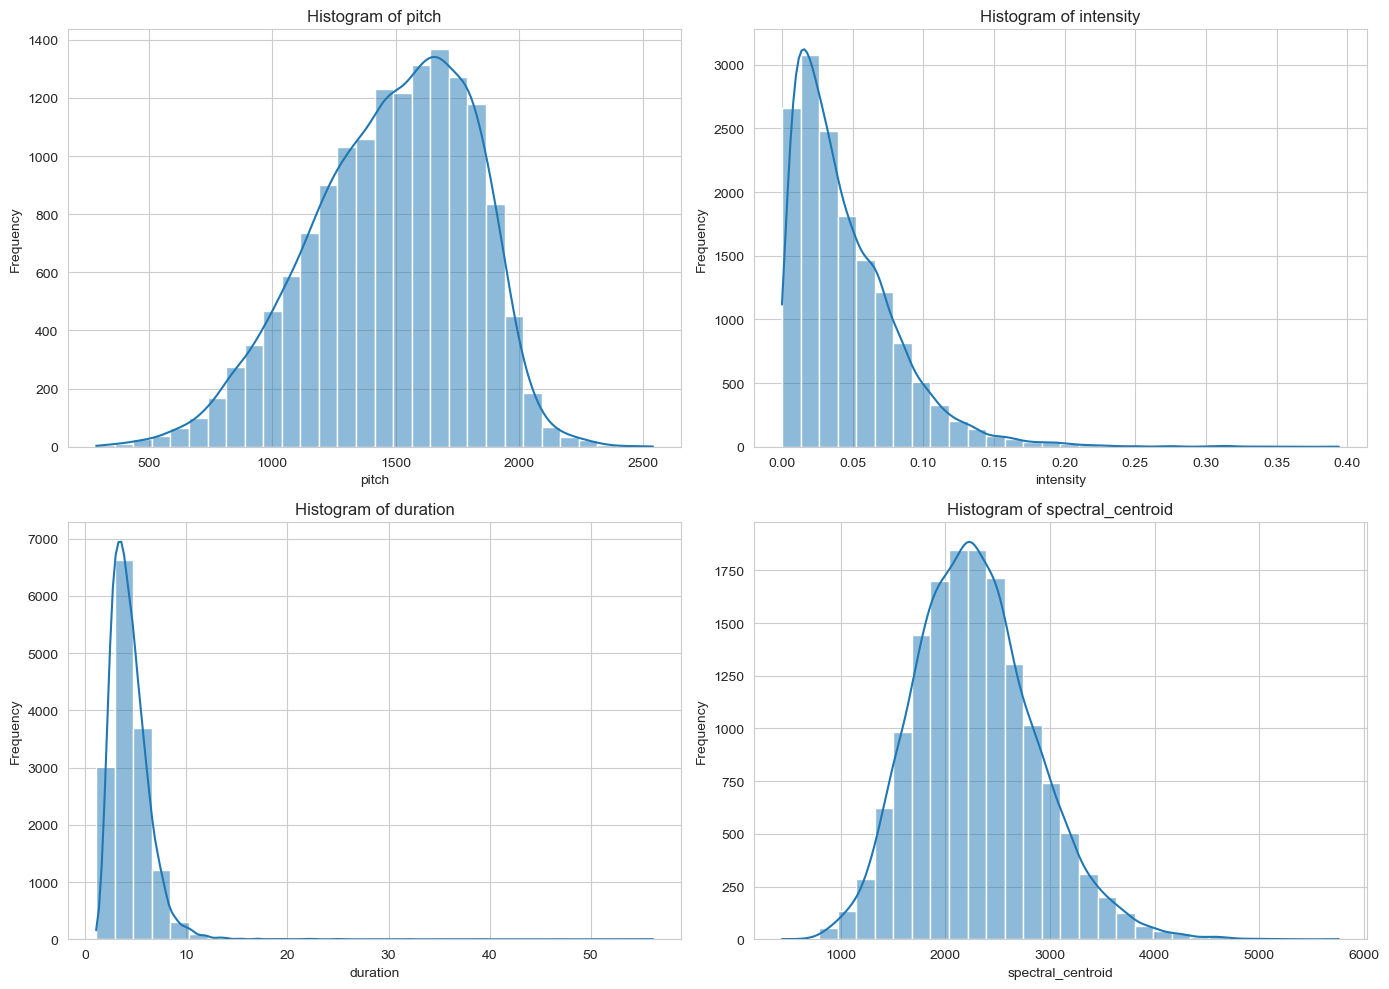

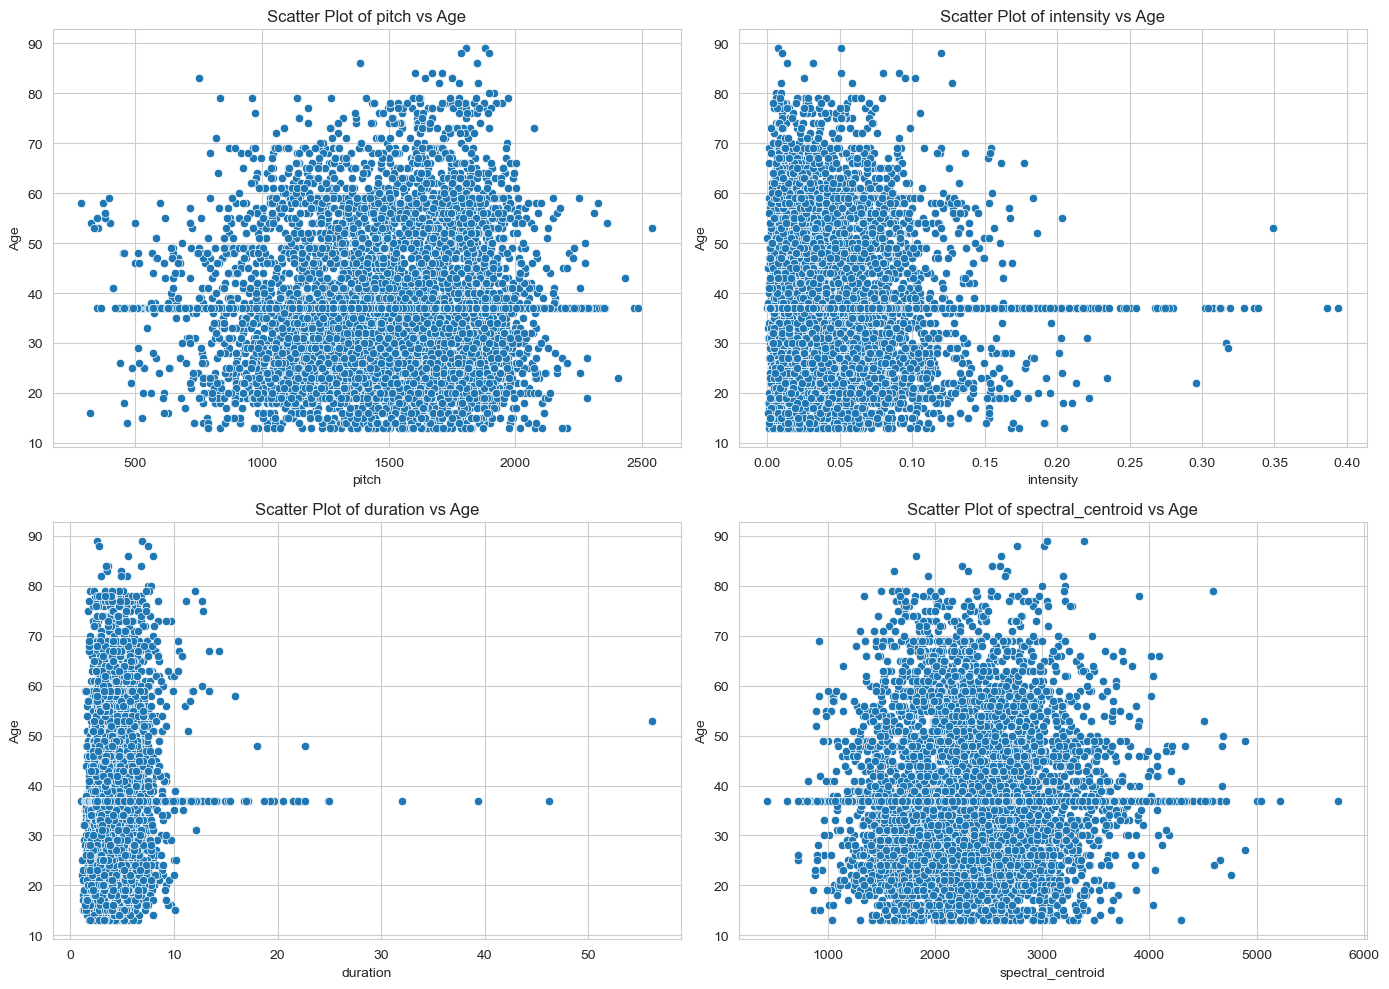

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
cols = ['pitch', 'intensity', 'duration', 'spectral_centroid']

for ax, col in zip(axes.flatten(), cols):
    sns.histplot(df[col], bins=30, kde=True, ax=ax)
    ax.set_title(f'Histogram of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
cols = ['pitch', 'intensity', 'duration', 'spectral_centroid']

for ax, col in zip(axes.flatten(), cols):
    sns.scatterplot(data=data, x=col, y='age', ax=ax) 
    ax.set_title(f'Scatter Plot of {col} vs Age')
    ax.set_xlabel(col)
    ax.set_ylabel('Age')

plt.tight_layout()
plt.show()


In [ ]:
def detect_outliers(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    return ((column < lower_bound) | (column > upper_bound))

outliers_pitch = detect_outliers(data['pitch'])
print("Number of outliers in 'pitch':", outliers_pitch.sum())


skewness = data.skew()
print("Skewness of each column:\n", skewness)

df_transformed = data.copy()
df_transformed['intensity'] = data['intensity'].apply(np.log1p)

Number of outliers in 'pitch': 68
Skewness of each column:
 pitch               -0.433106
intensity            1.856806
duration             3.854956
spectral_centroid    0.471562
age                  1.057162
dtype: float64


C:\Users\Probook\AppData\Local\Temp\ipykernel_16284\3042184661.py:19: FutureWarning: The default value of numeric_only in DataFrame.skew is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  skewness = data.skew()


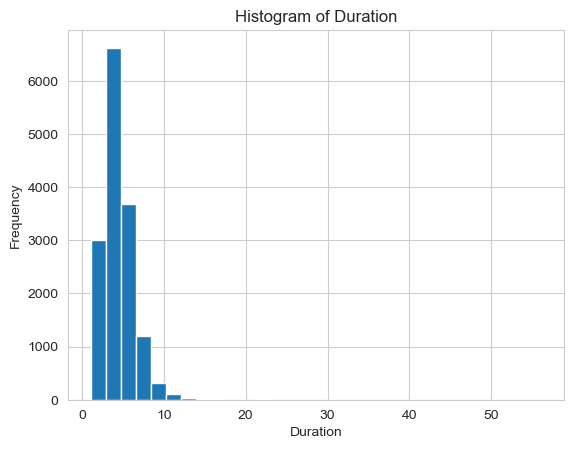

In [ ]:
plt.hist(data['duration'], bins=30)
plt.title('Histogram of Duration')
plt.xlabel('Duration')
plt.ylabel('Frequency')
plt.show()

In [ ]:
correlation_matrix = data.corr()
print("Correlation matrix:\n", correlation_matrix)

Correlation matrix:
                       pitch  intensity  duration  spectral_centroid       age
pitch              1.000000  -0.068814  0.008104           0.478207  0.033839
intensity         -0.068814   1.000000 -0.030902          -0.190804 -0.032807
duration           0.008104  -0.030902  1.000000          -0.001873  0.082995
spectral_centroid  0.478207  -0.190804 -0.001873           1.000000  0.034343
age                0.033839  -0.032807  0.082995           0.034343  1.000000


C:\Users\Probook\AppData\Local\Temp\ipykernel_16284\1577302103.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = data.corr()


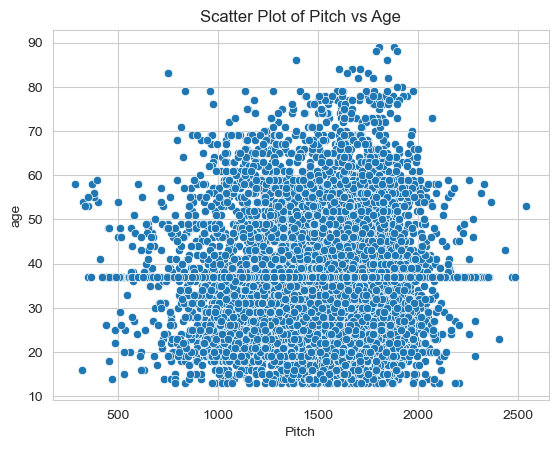

In [ ]:
sns.scatterplot(data=data, x='pitch', y='age')
plt.title('Scatter Plot of Pitch vs Age')
plt.xlabel('Pitch')
# plt.ylabel('Age')
plt.show()

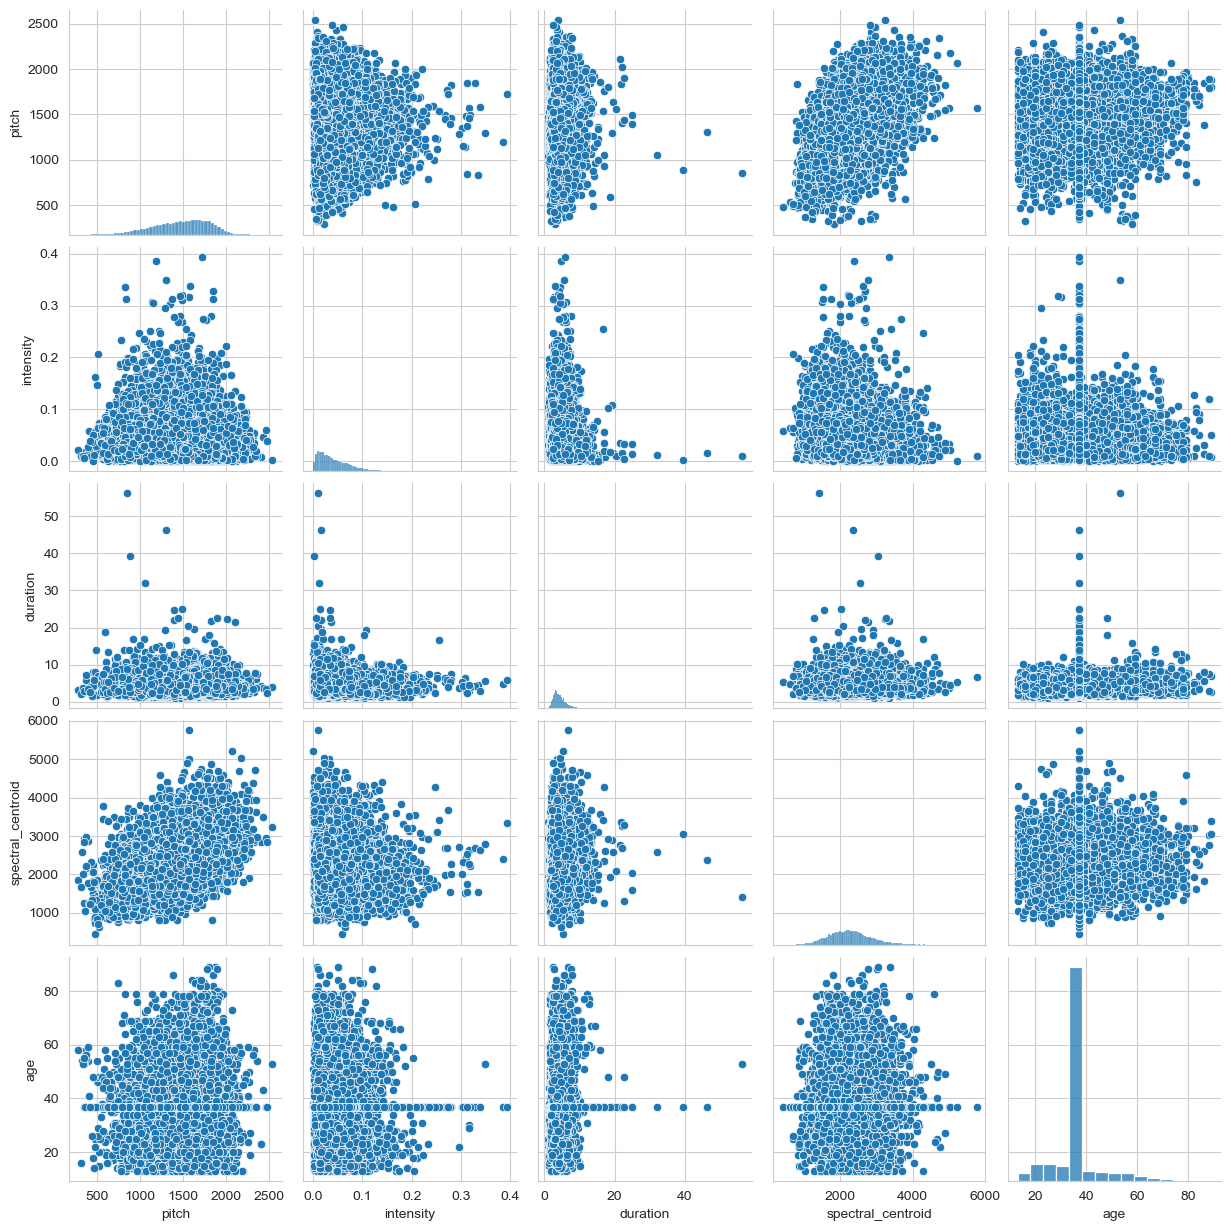

In [ ]:
sns.pairplot(data[['pitch', 'intensity', 'duration', 'spectral_centroid', 'age']])
plt.show()

In [ ]:
high_corr = correlation_matrix.abs() > 0.8
print("High correlations:\n", high_corr)

High correlations:
                    pitch  intensity  duration  spectral_centroid    age
pitch               True      False     False              False  False
intensity          False       True     False              False  False
duration           False      False      True              False  False
spectral_centroid  False      False     False               True  False
age                False      False     False              False   True


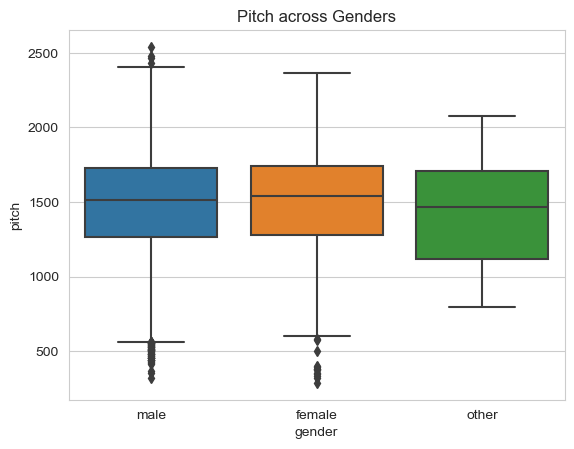

In [ ]:
sns.boxplot(x='gender', y='pitch', data=data)
plt.title('Pitch across Genders')
plt.show()

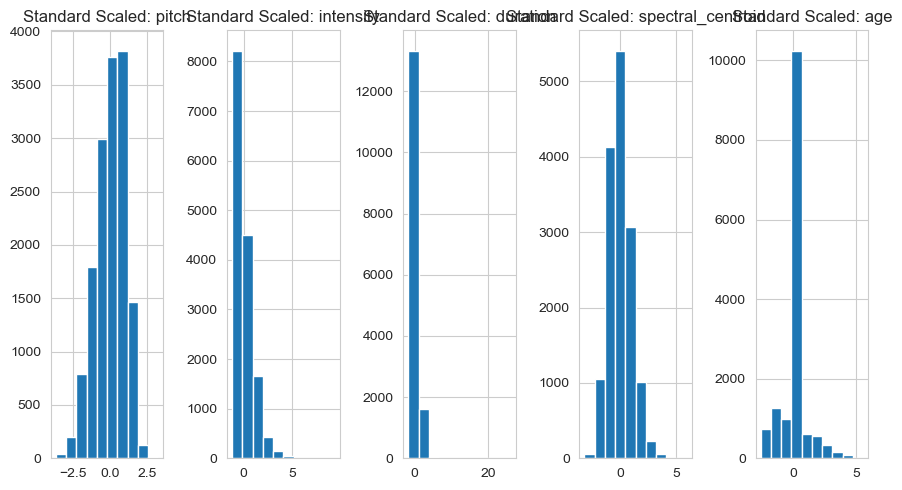

In [ ]:
df = pd.read_csv("C:\\Users\\Probook\\Downloads\\updated_data.csv")

def standard_scaling(series):
    if pd.api.types.is_numeric_dtype(series):
        return (series - series.mean()) / series.std()
    return series

df_standard_scaled = df.apply(standard_scaling)

fig, axes = plt.subplots(nrows=1, ncols=len(df_standard_scaled.columns), figsize=(12, 5))

for col, ax in zip(df_standard_scaled.columns, axes.flatten()):
    if pd.api.types.is_numeric_dtype(df_standard_scaled[col]):
        df_standard_scaled[col].hist(ax=ax)
        ax.set_title(f'Standard Scaled: {col}')
    else:
        ax.set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
df = pd.read_csv("C:\\Users\\Probook\\Downloads\\updated_data.csv")

features = ['pitch', 'intensity', 'duration', 'spectral_centroid']
X = df[features].values
y = df['age'].values

class LinearRegression:
    def _init_(self):
        self.weights = None
    
    def fit(self, X, y):
        X = np.insert(X, 0, 1, axis=1)
        self.weights = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
    
    def predict(self, X):
        X = np.insert(X, 0, 1, axis=1)
        return X.dot(self.weights)

model = LinearRegression()
model.fit(X, y)

predictions = model.predict(X)
print(predictions)

def mean_squared_error(y_true, y_pred):
    return ((y_true - y_pred) ** 2).mean()

mse = mean_squared_error(y, predictions)
print(f"Mean Squared Error: {mse}")

[36.69287927 39.04507592 37.56617815 ... 37.03356921 37.69269645
 36.30155048]
Mean Squared Error: 87.18804132862486


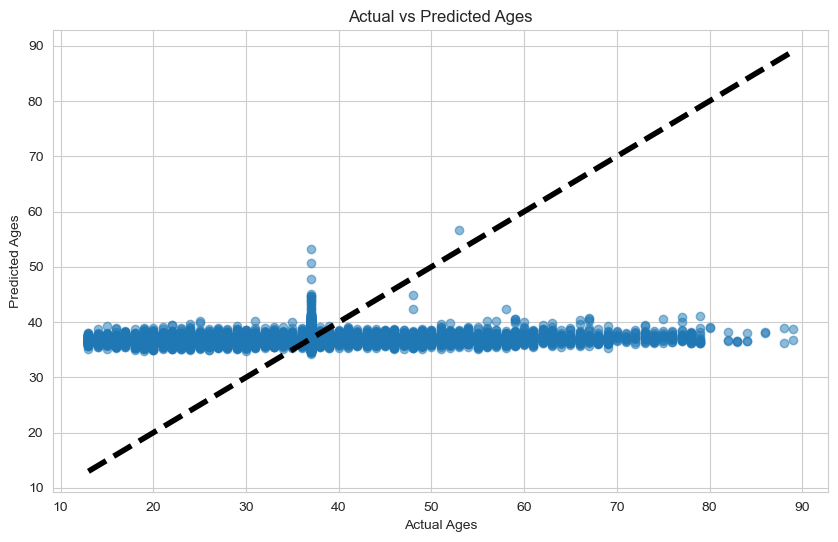

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y, predictions, alpha=0.5)
plt.title('Actual vs Predicted Ages')
plt.xlabel('Actual Ages')
plt.ylabel('Predicted Ages')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=4)
plt.show()

In [ ]:
df = pd.read_csv("C:\\Users\\Probook\\Downloads\\cv-valid-test.csv")

df['age'] = df['age'].apply(replace_age)

mean_age = df['age'].dropna().mean()
mode_accent = df['accent'].dropna().mode()[0]
mode_gender = data['gender'].dropna().mode()[0]

df['age'].fillna(mean_age, inplace=True)
df['accent'].fillna(mode_accent, inplace=True)
data['gender'].fillna(mode_gender, inplace=True)

df['age'] = df['age'].astype(int)

df.to_csv("C:\\Users\\Probook\\Downloads\\cv-valid-test.csv", index=False)
df


,filename,text,up_votes,down_votes,age,gender,accent,duration
0,cv-valid-test/sample-000000.mp3,without the dataset the article is useless,1,0,36,NaN,us,NaN
1,cv-valid-test/sample-000001.mp3,i've got to go to him,1,0,25,male,us,NaN
2,cv-valid-test/sample-000002.mp3,and you know it,1,0,36,NaN,us,NaN
3,cv-valid-test/sample-000003.mp3,down below in the darkness were hundreds of pe...,4,0,28,male,us,NaN
4,cv-valid-test/sample-000004.mp3,hold your nose to keep the smell from disablin...,2,0,36,NaN,us,NaN
...,...,...,...,...,...,...,...,...
3990,cv-valid-test/sample-003990.mp3,the old man opened his cape and the boy was st...,1,0,36,NaN,us,NaN
3991,cv-valid-test/sample-003991.mp3,in alchemy it's called the soul of the world,2,1,36,NaN,us,NaN
3992,cv-valid-test/sample-003992.mp3,at that point in their lives everything is cle...,3,0,36,NaN,us,NaN
3993,cv-valid-test/sample-003993.mp3,he told them all to be seated,3,0,36,NaN,us,NaN


In [ ]:
test_df = pd.read_csv("C:\\Users\\Probook\\Downloads\\cv-valid-test.csv")

features = ['pitch', 'intensity', 'duration', 'spectral_centroid']
X_test = test_df[features].values
y_test = test_df['age'].values

predictions = model.predict(X_test)

def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def mean_absolute_error(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

mse = mean_squared_error(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
r2 = r_squared(y_test, predictions)

print(f"Mean Squared Error (MSE): {mse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R-squared: {r2}")

In [ ]:
test_df['predicted_age'] = predictions

age_group_results = test_df.groupby('age_group').apply(
    lambda x: pd.Series({
        'MSE': mean_squared_error(x['age'], x['predicted_age']),
        'MAE': mean_absolute_error(x['age'], x['predicted_age']),
        'R2': r_squared(x['age'], x['predicted_age'])
    })
)

print(age_group_results)